In [1]:
# !pip uninstall -y torch torchvision torchaudio
# !pip cache purge || true
# !pip install --no-cache-dir --upgrade --force-reinstall "torch==2.8.0" "torchvision==0.23.0" -f https://download.pytorch.org/whl/torch_stable.html
# !pip install facenet-pytorch

In [2]:

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
from glob import glob
# from PIL import Image
import torchvision.transforms as T
import cv2
import dlib
import torch
# from imutils.face_utils import FaceAligner
import imutils
from tqdm.notebook import tqdm # Utilise tqdm.notebook pour un affichage adapté
import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))


In [3]:
# Télécharger le modèle de landmarks de dlib
if not os.path.exists("shape_predictor_68_face_landmarks.dat"):
    # Commande pour télécharger le fichier de modèle
    !wget http://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2
    !bzip2 -d shape_predictor_68_face_landmarks.dat.bz2

# Initialisation des détecteurs
detector = dlib.get_frontal_face_detector()
predictor = dlib.shape_predictor('shape_predictor_68_face_landmarks.dat')

--2025-09-23 18:38:20--  http://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2
Resolving dlib.net (dlib.net)... 107.180.26.78
Connecting to dlib.net (dlib.net)|107.180.26.78|:80... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2 [following]
--2025-09-23 18:38:20--  https://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2
Connecting to dlib.net (dlib.net)|107.180.26.78|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 64040097 (61M)
Saving to: ‘shape_predictor_68_face_landmarks.dat.bz2’

shape_predictor_68_ 100%[===================>]  61.07M  37.8MB/s    in 1.6s    

2025-09-23 18:38:22 (37.8 MB/s) - ‘shape_predictor_68_face_landmarks.dat.bz2’ saved [64040097/64040097]



In [4]:
# Définition des chemins d'entrée et de sortie
# Les datasets Kaggle sont montés ici
INPUT_DIR = '/kaggle/input/anip-reconnaissance-faciale-estimation-age-ocr/dataset_tache_1/dataset_tache_1'
TRAIN_DIR = os.path.join(INPUT_DIR, 'train')
TEST_DIR = os.path.join(INPUT_DIR, 'test')
# Seul le répertoire /kaggle/working/ est inscriptible
OUTPUT_DIR = '/kaggle/working'

In [5]:
!pip install facenet-pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 40.1 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 61.3 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 755.6/755.6 MB 2.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 3.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 76.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 46.6 MB/s eta 0:00:0000:0100:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 28.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 MB 2.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 8.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 31.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 13.9 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━

# Modèle Pré-entraîné

In [6]:
# from facenet_pytorch import InceptionResnetV1, MTCNN

In [7]:
# # Télécharger et initialiser le modèle FaceNet
# # Ce modèle est pré-entraîné sur le dataset VGGFace2.
# model = InceptionResnetV1(pretrained='vggface2').eval()
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# model.to(device)

# # Initialiser le détecteur de visages (MTCNN est souvent utilisé avec FaceNet)
# mtcnn = MTCNN(keep_all=True, device=device)

# Task 1: Face Recognition

"Face recognition is the process in which you match a human face from a digital image or a video frame against a database of faces."

Cet article illustre bien comment ça se passe. https://medium.com/data-science/face-recognition-using-deep-learning-b9be73689a23

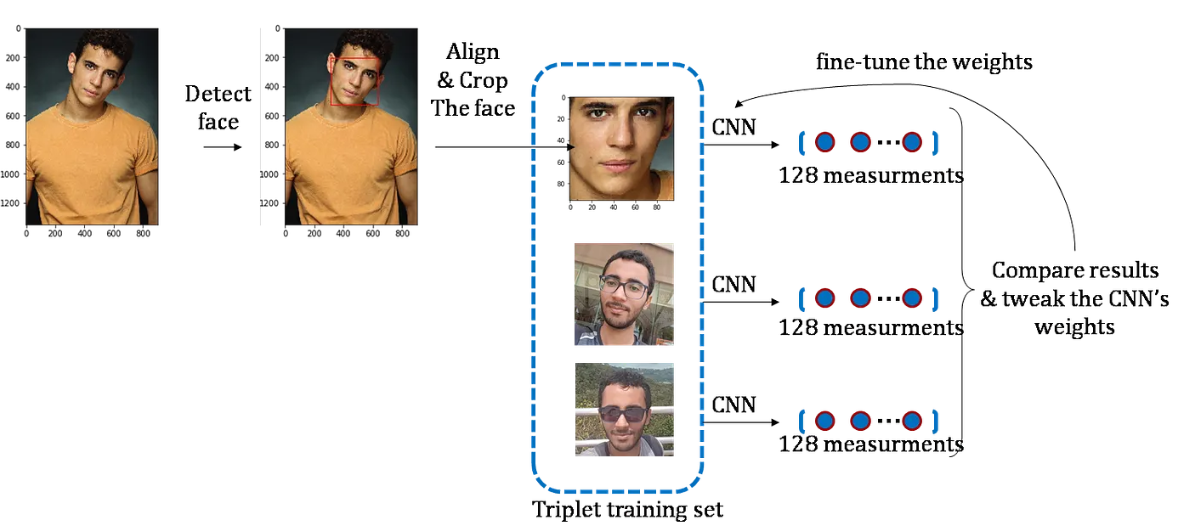

## Prétraitement de données

In [8]:
def process_image(image_path, detector, predictor, target_size=(224, 224)):
    """Détecte, aligne et redimensionne un visage dans une image."""
    image = cv2.imread(image_path)
    if image is None:
        return None
    
    # Détection et alignement
    faces = detector(image, 1)
    if len(faces) > 0:
        face = faces[0]
        landmarks = predictor(image, face)
        aligned_face = dlib.get_face_chip(image, landmarks, size=target_size[0])
        final_image = cv2.resize(np.array(aligned_face), target_size)
        return final_image
    return None

def create_in_memory_dataset(data_dir, detector, predictor):
    """Crée un DataFrame en mémoire avec les images prétraitées."""
    records = []
    # Utilisation de glob pour une recherche de fichiers simplifiée
    for img_path in tqdm(glob(os.path.join(data_dir, "*.jpg"))):
        fname = os.path.basename(img_path)
        processed_image = process_image(img_path, detector, predictor)
        
        if processed_image is not None:
            # Pour le dataset d'entraînement
            person_id, shot = None, None
            if '_' in fname:
                parts = fname.split('_')
                person_id = parts[0]
                shot = parts[1].split('.')[0]
            
            records.append({
                "id_personne": person_id,
                "shot": shot,
                "path": img_path,
                "image_data": processed_image
            })
    
    return pd.DataFrame(records)

print("Création du jeu de données d'entraînement en mémoire...")
df_train = create_in_memory_dataset(TRAIN_DIR, detector, predictor)

print("Création du jeu de données de test en mémoire...")
df_test = create_in_memory_dataset(TEST_DIR, detector, predictor)

print("Jeu de données d'entraînement (shape) :", df_train.shape)
print("Jeu de données de test (shape) :", df_test.shape)

Création du jeu de données d'entraînement en mémoire...


  0%|          | 0/4000 [00:00<?, ?it/s]

Création du jeu de données de test en mémoire...


  0%|          | 0/2000 [00:00<?, ?it/s]

Jeu de données d'entraînement (shape) : (3985, 4)
Jeu de données de test (shape) : (1990, 4)


##  Aperçu des images après le prétraitement

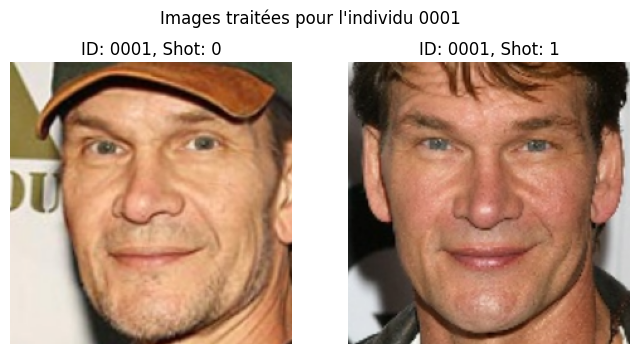

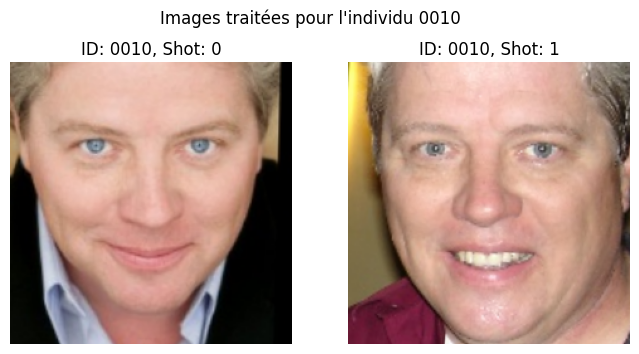

In [9]:
def plot_person_faces(df, person_id):
    """Affiche les deux images d'un individu après le prétraitement."""
    person_df = df[df['id_personne'] == person_id]
    if len(person_df) == 2:
        fig, axes = plt.subplots(1, 2, figsize=(8, 4))
        
        # Convertir BGR (OpenCV) en RGB pour matplotlib
        img1 = cv2.cvtColor(person_df.iloc[0]['image_data'], cv2.COLOR_BGR2RGB)
        img2 = cv2.cvtColor(person_df.iloc[1]['image_data'], cv2.COLOR_BGR2RGB)
        
        axes[0].imshow(img1)
        axes[0].set_title(f"ID: {person_id}, Shot: {person_df.iloc[0]['shot']}")
        axes[0].axis('off')
        
        axes[1].imshow(img2)
        axes[1].set_title(f"ID: {person_id}, Shot: {person_df.iloc[1]['shot']}")
        axes[1].axis('off')
        
        plt.suptitle(f"Images traitées pour l'individu {person_id}")
        plt.show()
    else:
        print(f"L'individu {person_id} n'a pas 2 images dans le DataFrame.")

# Exemples de visualisation
plot_person_faces(df_train, '0001') # Remplace '0001' par un ID de ton choix
plot_person_faces(df_train, '0010')

## Choix du modèle d'embedding et fine-tuning

In [10]:
import torch
import torch.nn as nn
from torchvision import transforms, models
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam
from facenet_pytorch import InceptionResnetV1
import torch.nn.functional as F

import math
from sklearn.model_selection import train_test_split

In [11]:

# --- Étape 3.1 : Modèle ArcFace et Loss ---
# Importation ou définition du modèle ArcFace(custom avec facenet)

class ArcFace(nn.Module):
    def __init__(self, num_classes, emb_size=512, s=64.0, m=0.50, easy_margin=False):
        super(ArcFace, self).__init__()
        self.backbone = InceptionResnetV1(pretrained='vggface2')
        self.s = s
        self.m = m
        self.weight = nn.Parameter(torch.FloatTensor(num_classes, emb_size))
        nn.init.xavier_uniform_(self.weight)

        self.easy_margin = easy_margin
        self.cos_m = math.cos(m)
        self.sin_m = math.sin(m)
        self.th = math.cos(math.pi - m)
        self.mm = math.sin(math.pi - m) * m

    def forward(self, input, label=None):
        features = self.backbone(input)
        cosine = F.linear(F.normalize(features), F.normalize(self.weight))
        if label is None:
            return features
        sine = torch.sqrt(1.0 - torch.pow(cosine, 2))
        phi = cosine * self.cos_m - sine * self.sin_m
        if self.easy_margin:
            phi = torch.where(cosine > 0, phi, cosine)
        else:
            phi = torch.where(cosine > self.th, phi, cosine - self.mm)
        one_hot = torch.zeros(cosine.size(), device=input.device)
        one_hot.scatter_(1, label.view(-1, 1).long(), 1)
        output = (one_hot * phi) + ((1.0 - one_hot) * cosine)
        output *= self.s
        return output


In [12]:
# --- Étape 3.2 : Préparation du Dataset PyTorch ---
class FaceDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform
        
    def __len__(self):
        return len(self.dataframe)
    
    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        # Convertir en float32 et transposer (H, W, C) -> (C, H, W) pour PyTorch
        image = row['image_data'].astype(np.float32) / 255.0
        image = image.transpose((2, 0, 1))
        
        label = int(row['id_personne']) if row['id_personne'] is not None else -1
        
        image = torch.from_numpy(image)
        
        if self.transform:
            image = self.transform(image)
            
        return image, label

# Séparation des individus pour éviter le "data leakage"
unique_ids = df_train['id_personne'].unique()
train_ids, val_ids = train_test_split(unique_ids, test_size=0.2, random_state=42)

df_train_subset = df_train[df_train['id_personne'].isin(train_ids)]
df_val_subset = df_train[df_train['id_personne'].isin(val_ids)]

train_dataset = FaceDataset(df_train_subset)
val_dataset = FaceDataset(df_val_subset)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

In [13]:
# --- Étape 3.3 : Entraînement du modèle ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ArcFace(num_classes=len(unique_ids)).to(device)

# optimizer = Adam(model.parameters(), lr=0.001)

# num_epochs = 50
# for epoch in range(num_epochs):
#     model.train()
#     for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
#         inputs, labels = inputs.to(device), labels.to(device)
#         optimizer.zero_grad()
#         outputs = model(inputs, labels)
#         loss = F.cross_entropy(outputs, labels) # Utilise Cross-Entropy car la couche ArcFace fait le reste
#         loss.backward()
#         optimizer.step()
    
#     print(f"Epoch {epoch+1}/{num_epochs}, Loss: {loss.item():.4f}")

  0%|          | 0.00/107M [00:00<?, ?B/s]

In [22]:
# Sauvegarde le modèle fine-tuné
torch.save(model.state_dict(), 'model_task1.pth')

In [17]:
from sklearn.metrics.pairwise import cosine_similarity
import heapq  # Pour priority queue (max heap pour similarities)

def get_embeddings(df, model, device):
    # Ton code, mais avec charge on-the-fly comme dans FaceDataset
    class TestDataset(Dataset):
        def __init__(self, dataframe):
            self.dataframe = dataframe
        
        def __len__(self):
            return len(self.dataframe)
        
        def __getitem__(self, idx):
            row = self.dataframe.iloc[idx]
            image = cv2.imread(row['path'])
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            image = T.ToTensor()(image)
            image = T.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])(image)
            return image
    
    dataset = TestDataset(df)
    loader = DataLoader(dataset, batch_size=32, shuffle=False)
    
    model.eval()
    embeddings = []
    with torch.no_grad():
        for inputs in tqdm(loader, desc="Extraction des embeddings"):
            inputs = inputs.to(device)
            features = model(inputs, None)  # None pour get features
            embeddings.append(features.cpu().numpy())
    return np.concatenate(embeddings)

# Extraire embeddings test
embeddings_test = get_embeddings(df_test, model, device)

# Matrice de similarity
similarity_matrix = cosine_similarity(embeddings_test)

# Créer une list de tous les possible pairs (i, j, sim) avec i < j
pairs = []
for i in range(len(embeddings_test)):
    for j in range(i+1, len(embeddings_test)):
        sim = similarity_matrix[i, j]
        if sim > 0.6:  # Threshold comme dans ton code
            pairs.append((-sim, i, j))  # -sim pour max heap (highest first)

# Trier par similarity descending (using heap for efficiency)
heapq.heapify(pairs)

matched_pairs = []
paired = set()

while pairs:
    neg_sim, i, j = heapq.heappop(pairs)
    sim = -neg_sim
    if i not in paired and j not in paired:
        matched_pairs.append((i, j))
        paired.add(i)
        paired.add(j)

# Si pas exactement 1000 pairs, tu peux baisser le threshold ou analyser les restants
print(f"Nombre de pairs trouvés: {len(matched_pairs)}")

Extraction des embeddings:   0%|          | 0/63 [00:00<?, ?it/s]

Nombre de pairs trouvés: 880


Premières paires d'images correspondantes :
Image 1 : /kaggle/input/anip-reconnaissance-faciale-estimation-age-ocr/dataset_tache_1/dataset_tache_1/test/3159_0.jpg, Image 2 : /kaggle/input/anip-reconnaissance-faciale-estimation-age-ocr/dataset_tache_1/dataset_tache_1/test/3158_1.jpg


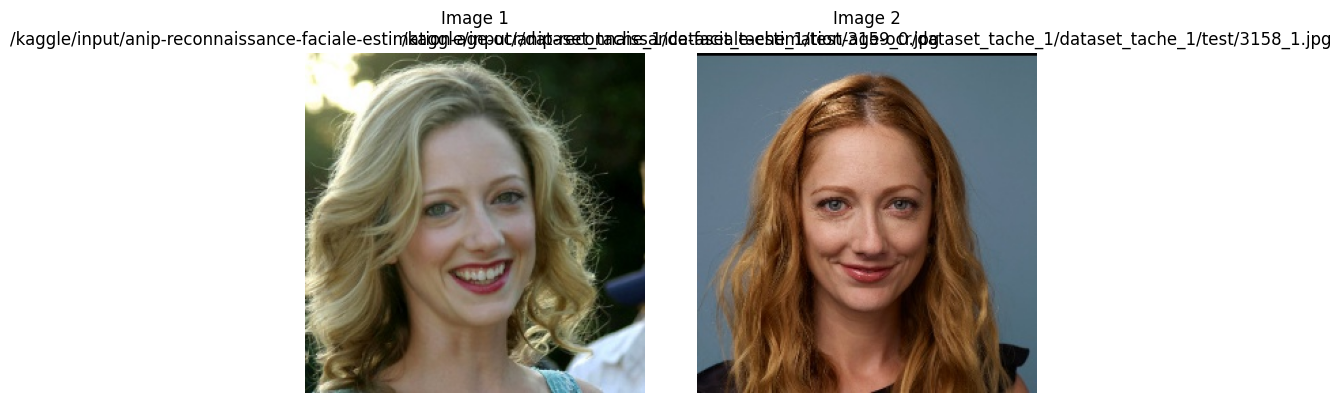

Image 1 : /kaggle/input/anip-reconnaissance-faciale-estimation-age-ocr/dataset_tache_1/dataset_tache_1/test/3177_1.jpg, Image 2 : /kaggle/input/anip-reconnaissance-faciale-estimation-age-ocr/dataset_tache_1/dataset_tache_1/test/3001_0.jpg


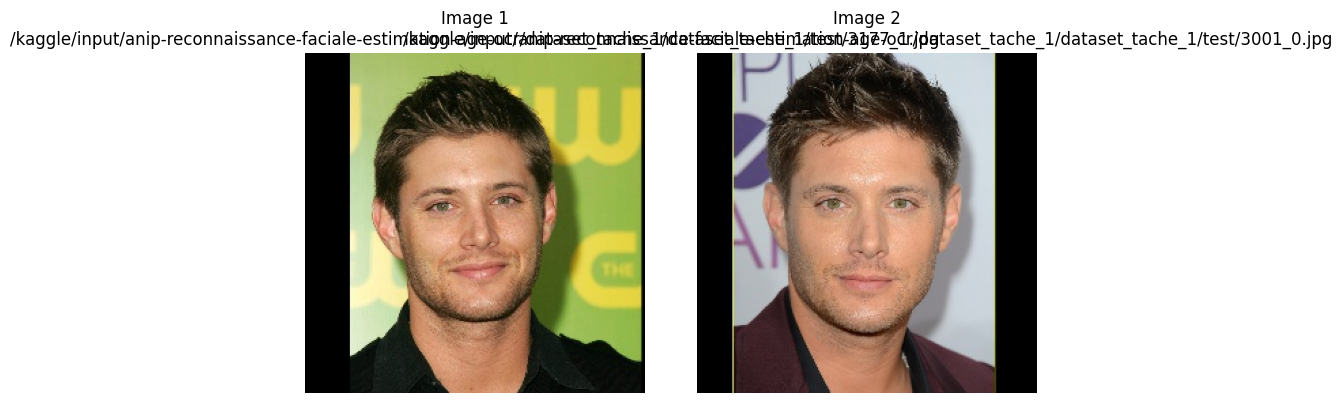

Image 1 : /kaggle/input/anip-reconnaissance-faciale-estimation-age-ocr/dataset_tache_1/dataset_tache_1/test/3005_1.jpg, Image 2 : /kaggle/input/anip-reconnaissance-faciale-estimation-age-ocr/dataset_tache_1/dataset_tache_1/test/3157_0.jpg


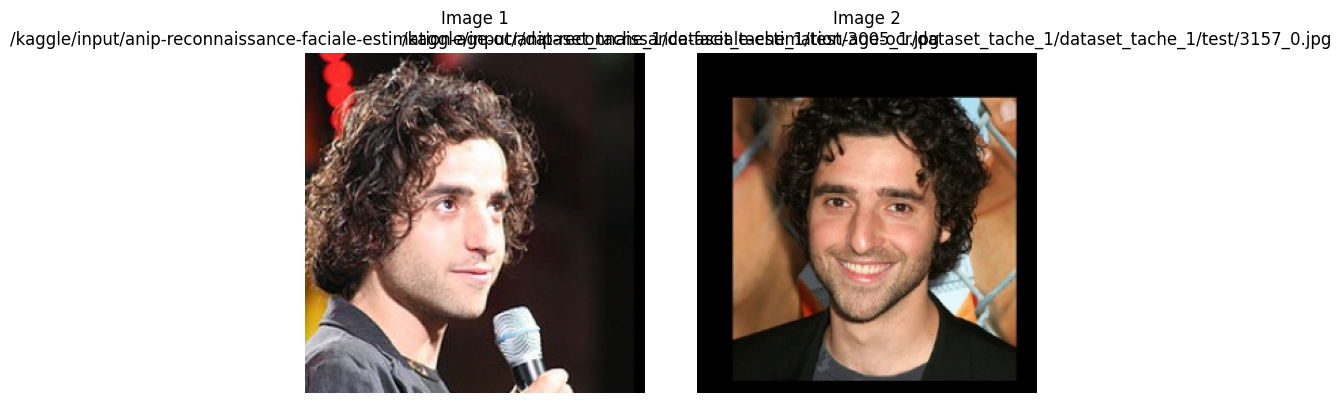

Image 1 : /kaggle/input/anip-reconnaissance-faciale-estimation-age-ocr/dataset_tache_1/dataset_tache_1/test/3341_1.jpg, Image 2 : /kaggle/input/anip-reconnaissance-faciale-estimation-age-ocr/dataset_tache_1/dataset_tache_1/test/3586_1.jpg


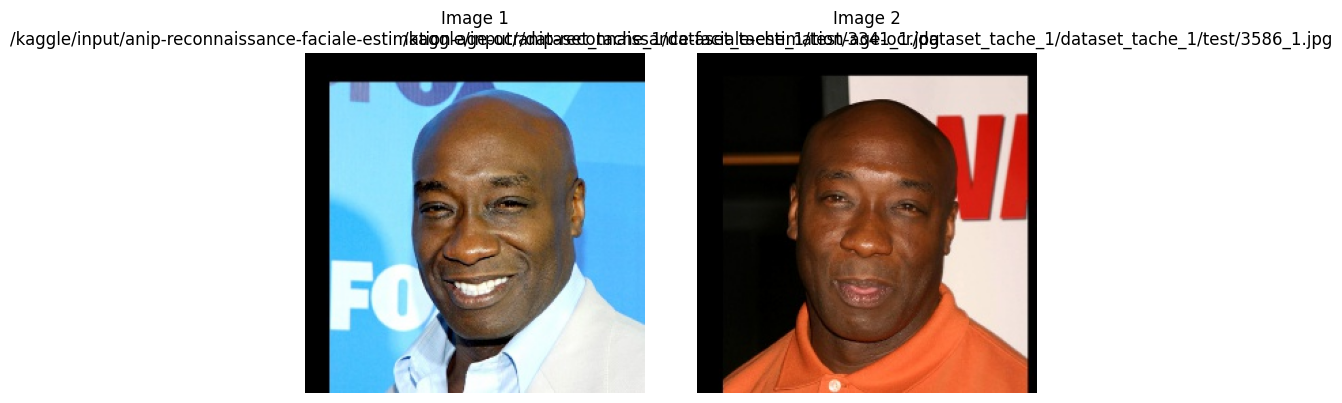

Image 1 : /kaggle/input/anip-reconnaissance-faciale-estimation-age-ocr/dataset_tache_1/dataset_tache_1/test/3153_1.jpg, Image 2 : /kaggle/input/anip-reconnaissance-faciale-estimation-age-ocr/dataset_tache_1/dataset_tache_1/test/3189_0.jpg


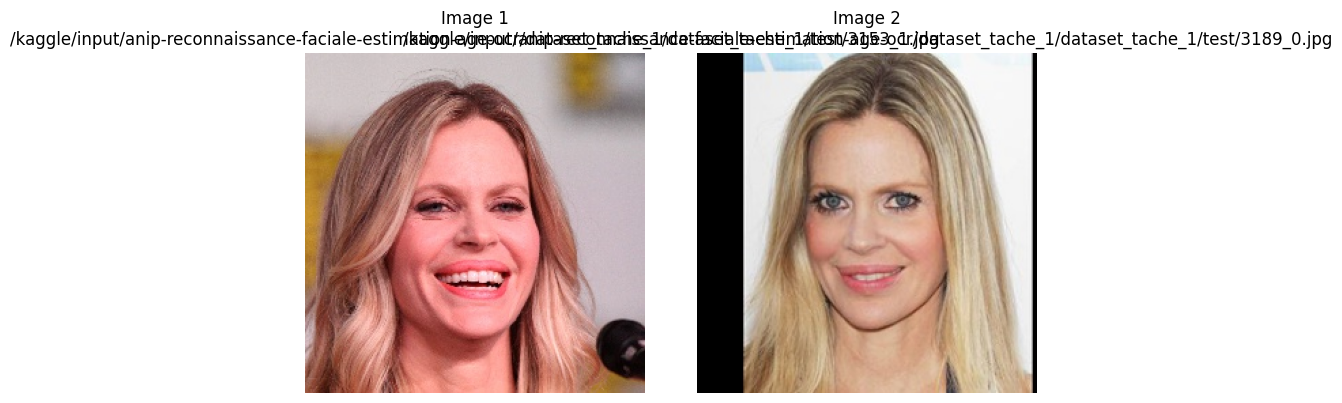

Image 1 : /kaggle/input/anip-reconnaissance-faciale-estimation-age-ocr/dataset_tache_1/dataset_tache_1/test/3353_1.jpg, Image 2 : /kaggle/input/anip-reconnaissance-faciale-estimation-age-ocr/dataset_tache_1/dataset_tache_1/test/3553_0.jpg


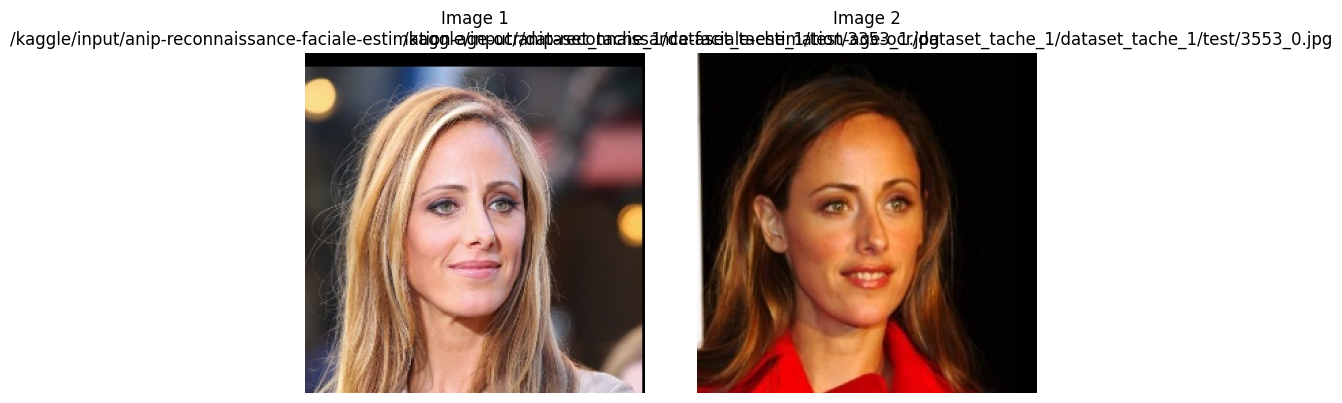

Image 1 : /kaggle/input/anip-reconnaissance-faciale-estimation-age-ocr/dataset_tache_1/dataset_tache_1/test/3152_0.jpg, Image 2 : /kaggle/input/anip-reconnaissance-faciale-estimation-age-ocr/dataset_tache_1/dataset_tache_1/test/3044_1.jpg


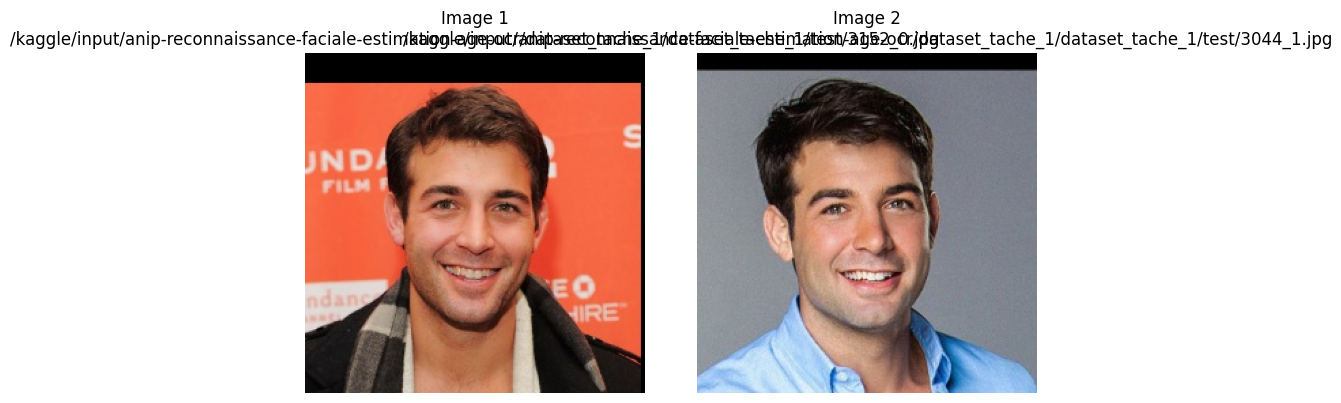

Image 1 : /kaggle/input/anip-reconnaissance-faciale-estimation-age-ocr/dataset_tache_1/dataset_tache_1/test/3322_1.jpg, Image 2 : /kaggle/input/anip-reconnaissance-faciale-estimation-age-ocr/dataset_tache_1/dataset_tache_1/test/3522_0.jpg


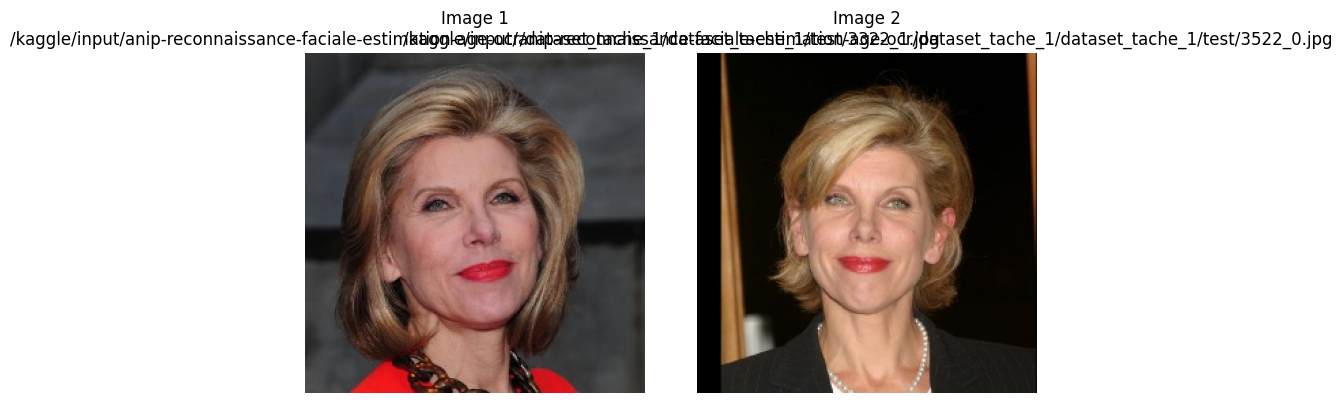

Image 1 : /kaggle/input/anip-reconnaissance-faciale-estimation-age-ocr/dataset_tache_1/dataset_tache_1/test/3650_0.jpg, Image 2 : /kaggle/input/anip-reconnaissance-faciale-estimation-age-ocr/dataset_tache_1/dataset_tache_1/test/3650_1.jpg


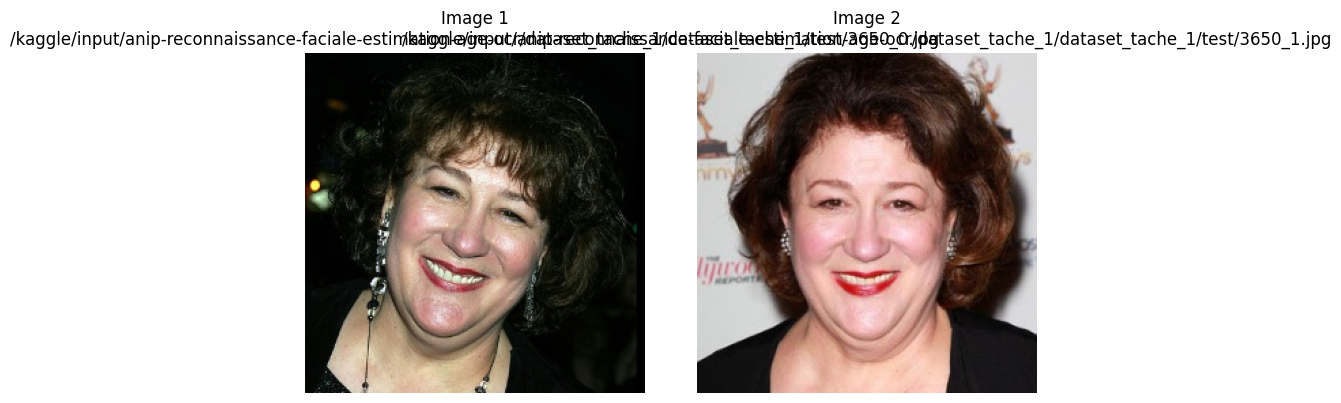

Image 1 : /kaggle/input/anip-reconnaissance-faciale-estimation-age-ocr/dataset_tache_1/dataset_tache_1/test/3319_0.jpg, Image 2 : /kaggle/input/anip-reconnaissance-faciale-estimation-age-ocr/dataset_tache_1/dataset_tache_1/test/3549_1.jpg


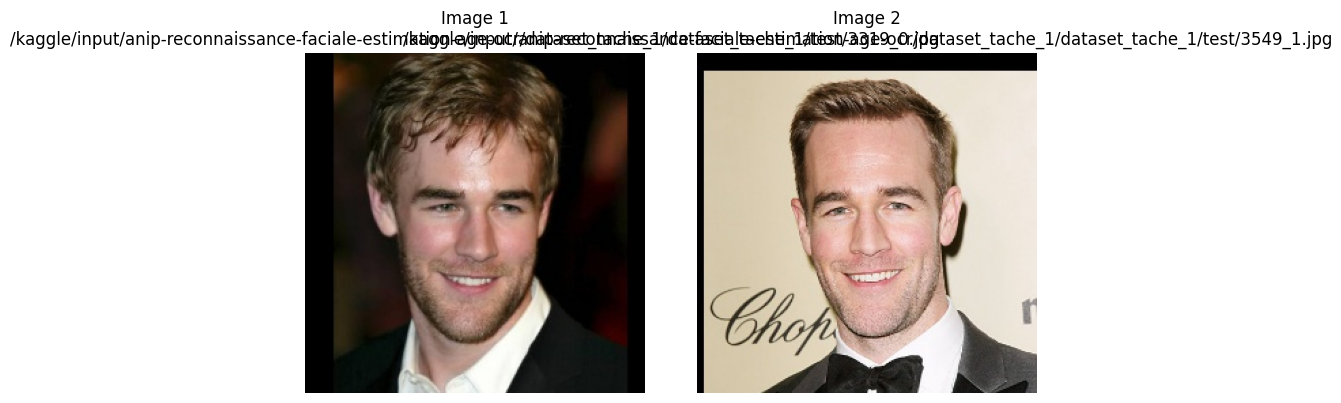

In [20]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Afficher les 5 premières paires
print("Premières paires d'images correspondantes :")
for i, pair in enumerate(matched_pairs[700:710]):
    idx1, idx2 = pair
    path1 = df_test.iloc[idx1]['path']
    path2 = df_test.iloc[idx2]['path']
    print(f"Image 1 : {path1}, Image 2 : {path2}")

    # Affichage des images côte à côte
    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    img1 = mpimg.imread(path1)
    img2 = mpimg.imread(path2)

    axes[0].imshow(img1)
    axes[0].set_title(f"Image 1\n{path1}")
    axes[0].axis('off')

    axes[1].imshow(img2)
    axes[1].set_title(f"Image 2\n{path2}")
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()


In [21]:
# Création du CSV
submission_data = []
for idx1, idx2 in matched_pairs:
    path1 = df_test.iloc[idx1]['path']
    path2 = df_test.iloc[idx2]['path']
    id1 = os.path.basename(path1).replace('.jpg', '')
    id2 = os.path.basename(path2).replace('.jpg', '')
    submission_data.append({'Shot1': id1, 'Shot2': id2})

df_submission = pd.DataFrame(submission_data)
df_submission.to_csv('submission_task1.csv', index=False)
print("✅ submission_task1.csv généré.")

✅ submission_task1.csv généré.
